In [1]:
from lcdb.db import LCDB
from lcdb.analysis import LearningCurve, LearningCurveGroup, LearningCurveExtractor, merge_curves
#from lcdb.analysis.json import 

import json

from tqdm import tqdm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
dfs = {}

d_datasets = set()

def f(r):
    if type(r) != str:
        return None
    s = (r.replace("'", '"').replace("], \"metrics", "]\", \"metrics").replace("values\": [", "values\": \"[ ").replace("True", "true").replace("False", "false"))
    return LearningCurve.from_json(s)

for k in [
    "lcdb.workflow.sklearn.KNNWorkflow",
    "lcdb.workflow.sklearn.LibLinearWorkflow",
    "lcdb.workflow.sklearn.LibSVMWorkflow",
    "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    "lcdb.workflow.xgboost.XGBoostWorkflow"
]:
    dfs[k] = pd.read_csv(f"{k}.csv")
    dfs[k]["learning_curve"] = dfs[k]["learning_curve"].apply(f)
    d_datasets |= set(pd.unique(dfs[k]["m:openmlid"]))

In [3]:
d_datasets = sorted(d_datasets)
d_workflows = sorted(dfs.keys())

In [4]:
import openml
from tqdm import tqdm

ds_meta_features = {}

for openmlid in tqdm(d_datasets):

    if openmlid not in ds_meta_features:
        # Load the dataset by ID
        dataset = openml.datasets.get_dataset(int(openmlid))  # Replace with your dataset ID

        # Get basic metadata
        ds_meta_features[openmlid] = dataset.qualities


100%|██████████| 71/71 [00:00<00:00, 366.91it/s]


In [5]:
def get_ds_meta_features(openmlid):
    return ds_meta_features[openmlid]["NumberOfInstances"], ds_meta_features[openmlid]["NumberOfFeatures"], 

def get_data_complexity(openmlid):
    return ds_meta_features[openmlid]["NumberOfInstances"] * ds_meta_features[openmlid]["NumberOfFeatures"], 

In [6]:
import pandas as pd

#d_workflows = sorted(df_full.keys())
#d_datasets = set()
#for workflow in d_workflows:
#    d_datasets |= set([int(d) for d in pd.unique(df_full[workflow]["m:openmlid"])])
d_datasets = sorted(d_datasets, key=get_data_complexity)

In [7]:
mean_runtimes = np.zeros((len(d_workflows), len(d_datasets)))
num_datapoints = np.zeros((len(d_workflows), len(d_datasets)))
for i, workflow in enumerate(d_workflows):
    for j, openmlid in enumerate(d_datasets):
        df_detail = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        if len(df_detail) == 0:
            mean_runtimes[i, j] = np.nan
            num_datapoints[i, j] = 0
        else:
            num_datapoints[i, j] = len(df_detail[df_detail["has_result"]])
            mean_runtimes[i, j] = (df_detail["m:timestamp_end"] - df_detail["m:timestamp_start"]).mean()


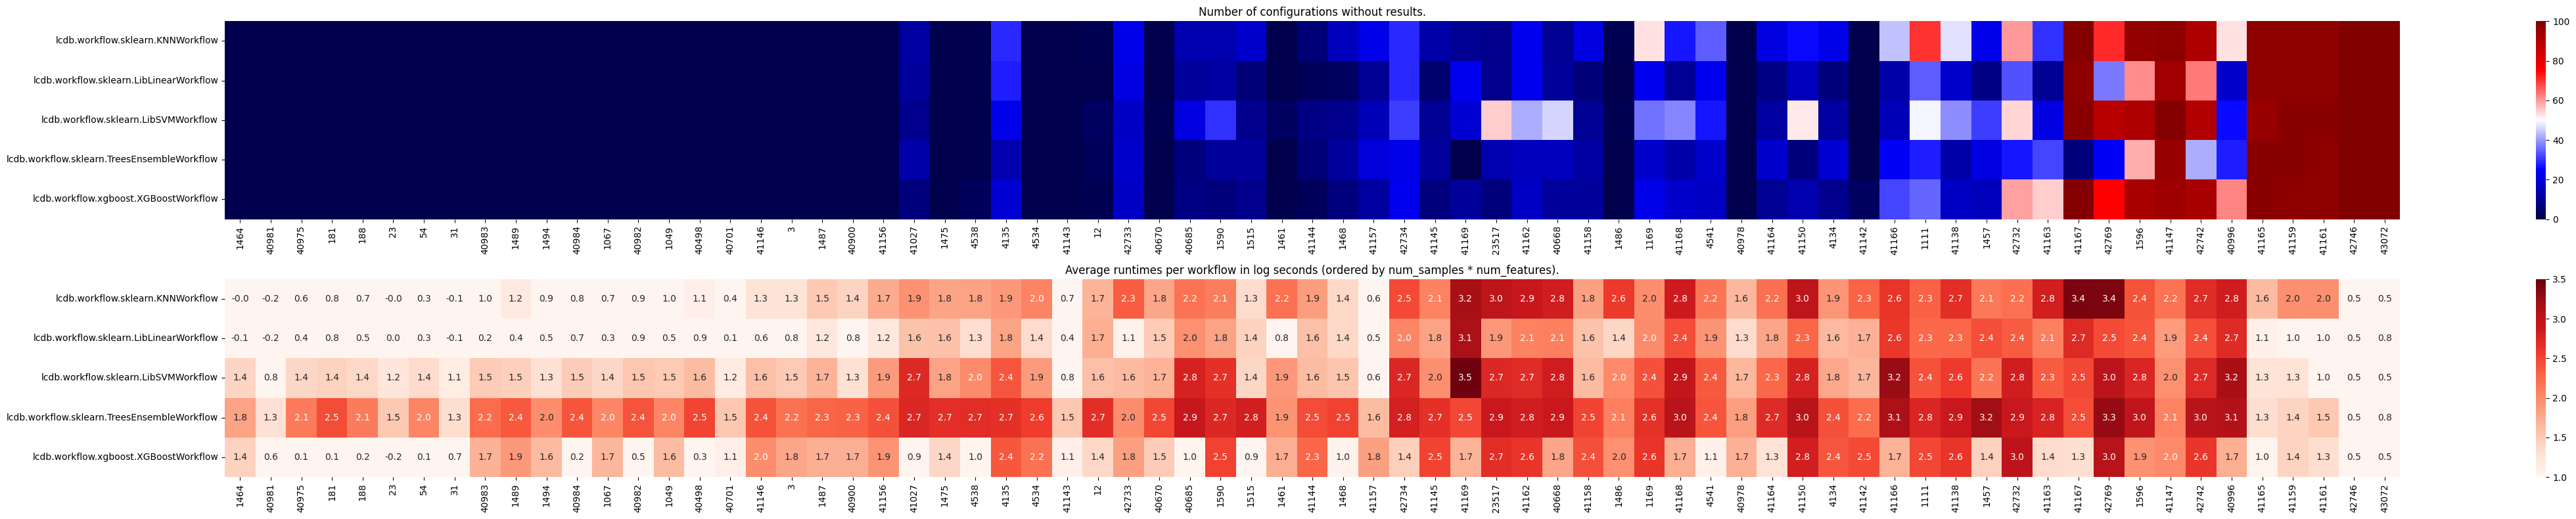

2211438.8997972673
252.44736299055563


In [8]:
import matplotlib.pyplot as plt
import seaborn as sb

fig, axs = plt.subplots(2, 1, figsize=(45, 8))

# show data availability
ax = axs[0]
sb.heatmap(100 - num_datapoints, ax=ax, cmap="seismic", center=50, vmin=0, vmax=100)
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Number of configurations without results.")

# show runtimes
ax = axs[1]
sb.heatmap(np.log10(mean_runtimes), ax=ax, cmap="Reds", annot=True, fmt=".1f", vmin=1, vmax=3.5)
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Average runtimes per workflow in log seconds (ordered by num_samples * num_features).")

fig.tight_layout()
plt.show()

print((np.nansum(mean_runtimes) * 10**5) / 3600)
print((np.nansum(mean_runtimes) * 10**5) / 86400 / 365)



In [ ]:
from lcdb.analysis.views._debugger import Debugger
workflow = "lcdb.workflow.sklearn.KNNWorkflow"
df_debug = dfs[workflow][dfs[workflow]["m:openmlid"] == 41167]
df_debug[df_debug["m:timestamp_end"] - df_debug["m:timestamp_start"] < 10]
debugger = Debugger()
debugger.load_data(df=df_debug)


In [13]:
debugger.df

,p:metric,p:n_neighbors,p:pp@cat_encoder,p:pp@decomposition,p:pp@featureselector,p:pp@scaler,p:weights,p:p,p:pp@feature_map_size,p:pp@featuregen,...,m:test_seed,m:timestamp_start,m:timestamp_end,m:memory,m:build_issues,m:timestamp_gather,has_result,learning_curve,payload,m:traceback
6100,minkowski,5,none,ka_nystroem,none,std,uniform,2.0,766.0,none,...,0,1.752685e+09,1.752685e+09,1761652736,NaN,5.424726,False,None,4,NaN
6101,minkowski,5,onehot,fastica,none,none,uniform,2.0,1.0,poly,...,0,1.752685e+09,1.752685e+09,2405531648,NaN,5.728116,False,None,4,NaN
6102,minkowski,5,onehot,kernel_pca,selectp,none,uniform,2.0,1.0,none,...,0,1.752685e+09,1.752685e+09,2128146432,NaN,5.927084,False,None,4,NaN
6103,minkowski,5,none,lda,none,none,uniform,2.0,1.0,none,...,0,1.752685e+09,1.752685e+09,2370514944,NaN,7.223872,False,None,4,NaN
6104,minkowski,5,ordinal,lda,none,minmax,uniform,2.0,1.0,poly,...,0,1.752685e+09,1.752685e+09,2408652800,NaN,8.697934,False,None,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6195,minkowski,1,ordinal,ka_nystroem,selectp,std,distance,7.0,653.0,none,...,0,1.752685e+09,1.752685e+09,2133352448,NaN,10.536821,False,None,4,"Traceback (most recent call last):\n File ""/g..."
6196,cosine,2,onehot,fastica,none,std,distance,2.0,1.0,poly,...,0,1.752685e+09,1.752688e+09,2499923968,NaN,10.536973,False,None,4,"Traceback (most recent call last):\n File ""/g..."
6197,cosine,3,onehot,none,none,none,distance,2.0,1.0,poly,...,0,1.752685e+09,1.752685e+09,1931206656,NaN,10.537131,False,None,4,"Traceback (most recent call last):\n File ""/g..."
6198,cosine,9,onehot,fastica,none,none,distance,2.0,1.0,none,...,0,1.752685e+09,1.752685e+09,2138689536,NaN,10.537287,False,None,4,"Traceback (most recent call last):\n File ""/g..."


# Extrapolate Compute
We extrapolate
$$\begin{align*}
    \mathbb{E}[\text{runtime on first c configs with first s seed combinations}] &= \mathbb{E}\left[\sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\text{ runtime of first c configs of workflow on }\mathit{D}\text{ and seed combination}\right]\\
    &= \sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and seed combination}\right]\\
    &\approx |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]\\
    &\approx c\cdot |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{any config of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]
\end{align*}
$$
Here we assume that the expected runtime is the same for all configs and seeds, which is the case if we do not condition on specific such configs and seeds.

This motivates to create a matrix with estimates of mean runtimes, which would be the estimates of the $\mathbb{E}$ in the sum.

Overall expected runtime for 5 test seeds, 5 validation seeds, 1 workflow seeds, and 100000 configs overall is 55.3 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.KNNWorkflow is 12.1 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.LibLinearWorkflow is 4.6 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.LibSVMWorkflow is 12.6 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.TreesEnsembleWorkflow is 19.7 million CPU hours
	Overall expected runtime for lcdb.workflow.xgboost.XGBoostWorkflow is 6.3 million CPU hours


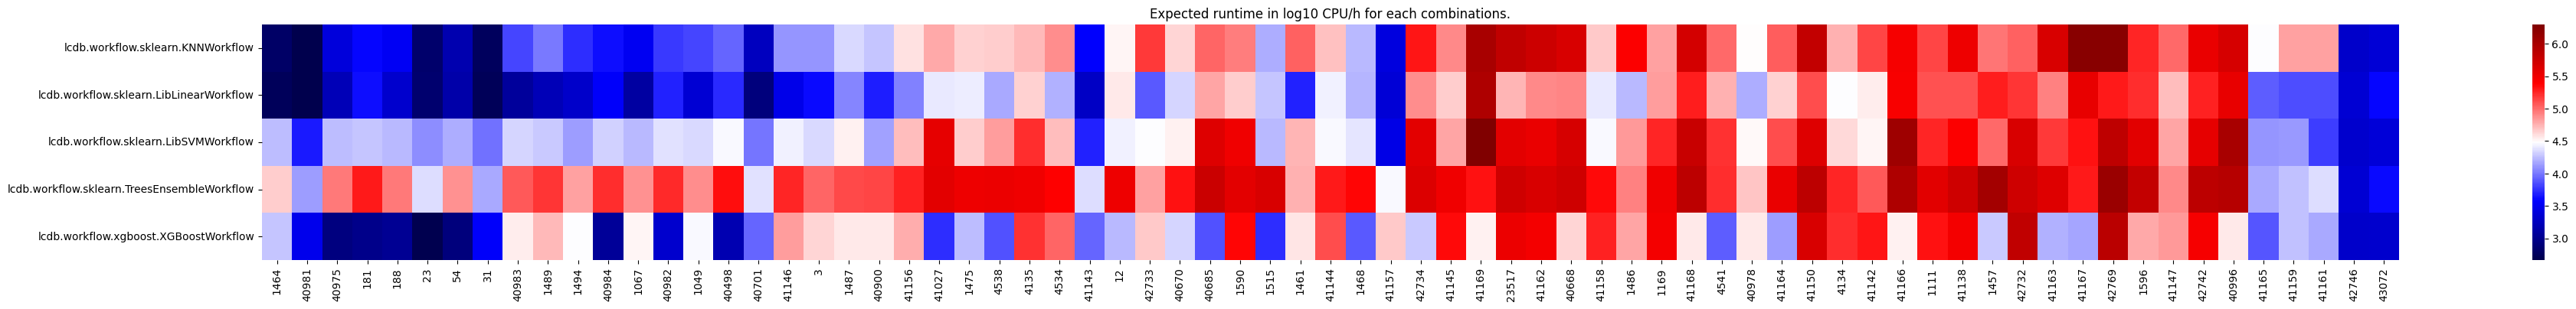

In [79]:
num_test_seeds_to_extrapolate_to = 5
num_valid_seeds_to_extrapolate_to = 5
num_workflow_seeds_to_extrapolate_to = 1
num_configs_to_extrapolate_to = 10**5
total_expected_entries = num_test_seeds_to_extrapolate_to * num_valid_seeds_to_extrapolate_to * num_workflow_seeds_to_extrapolate_to * num_configs_to_extrapolate_to
ratio_available_entries = num_datapoints / total_expected_entries

fig, ax = plt.subplots(1, 1, figsize=(45, 4))

# show data availability
expected_overall_runtimes = (mean_runtimes * total_expected_entries) / 3600
expected_remaining_runtimes = expected_overall_runtimes * (1 - ratio_available_entries)
sb.heatmap(np.log10(expected_remaining_runtimes), ax=ax, cmap="seismic")
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Expected runtime in log10 CPU/h for each combinations.")

print(f"Overall expected runtime for {num_test_seeds_to_extrapolate_to} test seeds, {num_valid_seeds_to_extrapolate_to} validation seeds, {num_workflow_seeds_to_extrapolate_to} workflow seeds, and {num_configs_to_extrapolate_to} configs overall is {np.round(np.sum(expected_overall_runtimes) / 10**6, 1)} million CPU hours")
for i, workflow in enumerate(d_workflows):
    print(f"\tOverall expected runtime for {workflow} is {np.round(np.sum(expected_overall_runtimes[i]) / 10**6, 1)} million CPU hours")